## 외부 인구 밀집 vs 내부 구조 복잡도 비교 분석
"지역 밀집과의 연결이 약하다면, 구조 복잡도가 더 관련 있는가?"
- 역사운영 현황 데이터 활용
- 환승 여부 / 층수 / 출입구 수

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

import koreanize_matplotlib

from scipy.stats import mannwhitneyu
from scipy.stats import pearsonr
import re

In [26]:
# 서울교통공사 역사운영 현황 데이터셋 불러오기
ops_raw = pd.read_csv("../../data/raw/서울교통공사_역사운영 현황_20250310.csv", encoding='cp949')

top_20_df = pd.read_csv("../../data/processed/team/top_20_df.csv")
candidate_df = top_20_df.copy()

In [27]:
# 역명 보정
ops_raw['지하철역'] = ops_raw['역명'].replace({
    '서울역': '서울',
    '구로디지털': '구로디지털단지'
})

In [28]:
# 층수 숫자화 함수
def parse_floor(x):
    x = str(x).strip().upper()
    if x == '' or x == 'NAN':
        return np.nan

    m = re.match(r'B(\d+)', x)
    if m:
        return int(m.group(1))

    m = re.match(r'(\d+)F', x)
    if m:
        return int(m.group(1))

    return np.nan

ops_raw['층수_num'] = ops_raw['층수'].apply(parse_floor)

In [29]:
# 역 단위로 집계
ops_station = ops_raw.groupby('지하철역', as_index=False).agg(
    층수_최대=('층수_num', 'max'),
    출입구_최대=('출입구', 'max'),
    면적_평균=('면적', 'mean'),
    운영행수=('지하철역', 'size')
)

In [30]:
# 후보역과 병합
q12_df = candidate_df.merge(ops_station, on='지하철역', how='left')

In [31]:
# 환승 여부
q12_df['환승여부'] = q12_df['호선명'].astype(str).apply(
    lambda x: '환승역' if ',' in x else '비환승역'
)

In [32]:
# 층수 구분: B3 이상이면 깊은 역
q12_df['층수구분'] = np.where(q12_df['층수_최대'] >= 3, '깊은 역', '얕은 역')

In [33]:
# 출입구 구분: 중앙값 기준 많음과 적음으로 분류
exit_median = q12_df['출입구_최대'].median()
q12_df['출입구구분'] = np.where(q12_df['출입구_최대'] >= exit_median, '출입구 많음', '출입구 적음')

q12_df.head()

,지하철역,호선명,총승차인원,무임승차인원,총하차인원,무임하차인원,전체승하차,무임승하차,무임승하차비중,EV,...,가중편의시설합,시설부하지수_순위,집중관리구역후보,층수_최대,출입구_최대,면적_평균,운영행수,환승여부,층수구분,출입구구분
0,종로5가,1,712905,247967,697910,240352,1410815,488319,34.61,3,...,12,1,True,2,8,10465.00,1,비환승역,얕은 역,출입구 많음
1,청량리,1,662997,280334,656727,281655,1319724,561989,42.58,2,...,14,2,True,2,6,8662.00,1,비환승역,얕은 역,출입구 적음
2,제기동,1,501317,269661,511782,290055,1013099,559716,55.25,3,...,14,3,True,2,8,7240.00,1,비환승역,얕은 역,출입구 많음
3,미아사거리,4,779304,190582,765423,190213,1544727,380795,24.65,2,...,10,4,True,2,6,8433.00,1,비환승역,얕은 역,출입구 적음
4,상계,4,567980,132469,528993,129123,1096973,261592,23.85,1,...,8,5,True,3,5,6650.15,1,비환승역,깊은 역,출입구 적음


In [34]:
# 요약표
q12_transfer_summary = q12_df.groupby('환승여부').agg(
    역수=('지하철역', 'count'),
    평균_시설부하지수=('시설부하지수', 'mean'),
    중앙값_시설부하지수=('시설부하지수', 'median')
).round(2)

q12_floor_summary = q12_df.groupby('층수구분').agg(
    역수=('지하철역', 'count'),
    평균_시설부하지수=('시설부하지수', 'mean'),
    중앙값_시설부하지수=('시설부하지수', 'median')
).round(2)

q12_exit_summary = q12_df.groupby('출입구구분').agg(
    역수=('지하철역', 'count'),
    평균_시설부하지수=('시설부하지수', 'mean'),
    중앙값_시설부하지수=('시설부하지수', 'median')
).round(2)

display(q12_transfer_summary)
display(q12_floor_summary)
display(q12_exit_summary)

,역수,평균_시설부하지수,중앙값_시설부하지수
환승여부,,,
비환승역,40,20743.20,18502.75
환승역,9,16795.55,16579.21


,역수,평균_시설부하지수,중앙값_시설부하지수
층수구분,,,
깊은 역,22,17753.86,16219.89
얕은 역,27,21863.08,18886.94


,역수,평균_시설부하지수,중앙값_시설부하지수
출입구구분,,,
출입구 많음,25,19593.78,17747.55
출입구 적음,24,20460.14,18677.12


In [35]:
# 검증
q12_test_results = []

# 환승 여부
stat, p = mannwhitneyu(
    q12_df[q12_df['환승여부'] == '환승역']['시설부하지수'],
    q12_df[q12_df['환승여부'] == '비환승역']['시설부하지수'],
    alternative='two-sided'
)
q12_test_results.append({
    '구분': '환승역 vs 비환승역',
    '지표': '시설부하지수',
    '통계량': round(stat, 2),
    'p-value': round(p, 4)
})

In [36]:
# 층수 구분
stat, p = mannwhitneyu(
    q12_df[q12_df['층수구분'] == '깊은 역']['시설부하지수'],
    q12_df[q12_df['층수구분'] == '얕은 역']['시설부하지수'],
    alternative='two-sided'
)
q12_test_results.append({
    '구분': '깊은 역 vs 얕은 역',
    '지표': '시설부하지수',
    '통계량': round(stat, 2),
    'p-value': round(p, 4)
})

In [37]:
# 출입구 구분
stat, p = mannwhitneyu(
    q12_df[q12_df['출입구구분'] == '출입구 많음']['시설부하지수'],
    q12_df[q12_df['출입구구분'] == '출입구 적음']['시설부하지수'],
    alternative='two-sided'
)
q12_test_results.append({
    '구분': '출입구 많음 vs 적음',
    '지표': '시설부하지수',
    '통계량': round(stat, 2),
    'p-value': round(p, 4)
})

In [38]:
# 층수와 시설부하지수 상관계수
temp_floor = q12_df[['시설부하지수', '층수_최대']].dropna()
corr_floor, p_floor = pearsonr(temp_floor['시설부하지수'], temp_floor['층수_최대'])

# 출입구 수와 시설부하지수 상관계수
temp_exit = q12_df[['시설부하지수', '출입구_최대']].dropna()
corr_exit, p_exit = pearsonr(temp_exit['시설부하지수'], temp_exit['출입구_최대'])

print("층수 상관계수:", round(corr_floor, 3), "/ p-value:", round(p_floor, 4))
print("출입구 수 상관계수:", round(corr_exit, 3), "/ p-value:", round(p_exit, 4))

층수 상관계수: -0.164 / p-value: 0.2613
출입구 수 상관계수: -0.013 / p-value: 0.9297


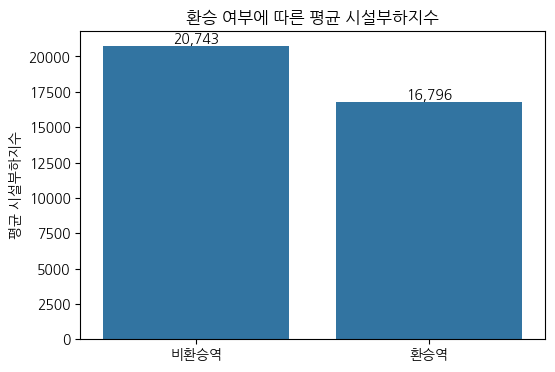

In [39]:
# 시각화

# 환승 여부
plt.figure(figsize=(6, 4))
ax = sns.barplot(data=q12_df, x='환승여부', y='시설부하지수', estimator=np.mean, errorbar=None)
plt.title('환승 여부에 따른 평균 시설부하지수')
plt.xlabel('')
plt.ylabel('평균 시설부하지수')

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:,.0f}',
                (p.get_x() + p.get_width()/2, height),
                ha='center', va='bottom', fontsize=10)

plt.show()

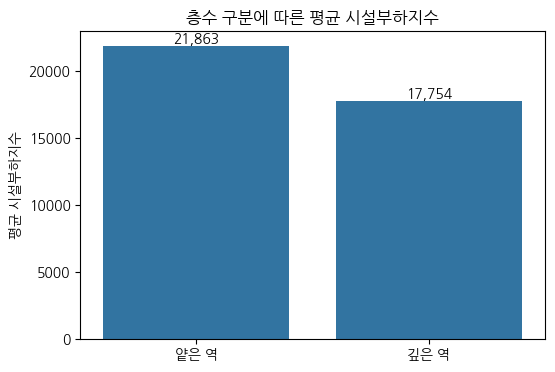

In [40]:
# 층수 구분
plt.figure(figsize=(6, 4))
ax = sns.barplot(data=q12_df, x='층수구분', y='시설부하지수', estimator=np.mean, errorbar=None)
plt.title('층수 구분에 따른 평균 시설부하지수')
plt.xlabel('')
plt.ylabel('평균 시설부하지수')

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:,.0f}',
                (p.get_x() + p.get_width()/2, height),
                ha='center', va='bottom', fontsize=10)

plt.show()

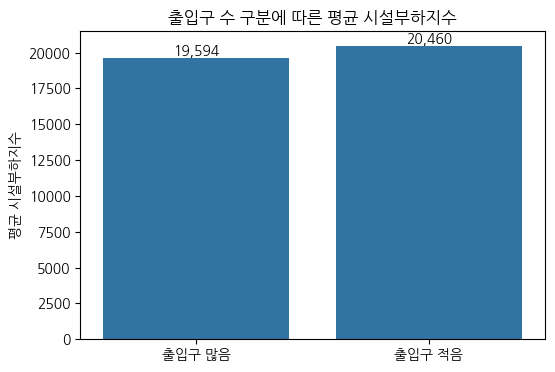

In [41]:
# 출입구 구분
plt.figure(figsize=(6, 4))
ax = sns.barplot(data=q12_df, x='출입구구분', y='시설부하지수', estimator=np.mean, errorbar=None)
plt.title('출입구 수 구분에 따른 평균 시설부하지수')
plt.xlabel('')
plt.ylabel('평균 시설부하지수')

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:,.0f}',
                (p.get_x() + p.get_width()/2, height),
                ha='center', va='bottom', fontsize=10)

plt.show()

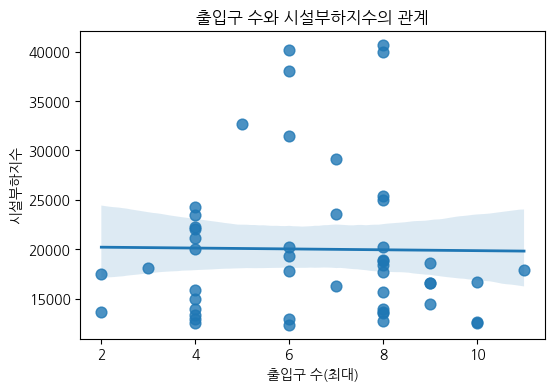

In [42]:
# 출입구 수와 시설부하지수 산점도
plt.figure(figsize=(6, 4))
sns.regplot(
    data=q12_df,
    x='출입구_최대',
    y='시설부하지수',
    scatter_kws={'s': 60},
    line_kws={'linewidth': 2}
)
plt.title('출입구 수와 시설부하지수의 관계')
plt.xlabel('출입구 수(최대)')
plt.ylabel('시설부하지수')
plt.show()